<a href="https://www.kaggle.com/code/setorcourage/ghana-revenue-tax-performance-analysis-1990-2022?scriptVersionId=331572642" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import requests

url = "https://api.worldbank.org/v2/country/GH/indicator/GC.TAX.TOTL.GD.ZS?format=json&per_page=50"

response = requests.get(url)
data = response.json()

records = []
for item in data[1]:
    records.append({
        'Year': item['date'],
        'Tax_Revenue_PCT_GDP': item['value'],
        'Country': item['country']['value']
    })

df = pd.DataFrame(records)
df = df.dropna()
df = df.sort_values('Year')
print(df.head(20))
df.to_csv('ghana_tax_revenue.csv', index=False)

    Year  Tax_Revenue_PCT_GDP Country
35  1990            11.436799   Ghana
34  1991            13.159596   Ghana
33  1992            10.768657   Ghana
32  1993            13.149247   Ghana
24  2001            17.192928   Ghana
23  2002            17.493111   Ghana
22  2003            18.477686   Ghana
21  2004            21.752106   Ghana
20  2005            21.321508   Ghana
19  2006            12.534619   Ghana
18  2007            13.877985   Ghana
17  2008            13.895968   Ghana
16  2009            12.612462   Ghana
15  2010            13.388387   Ghana
14  2011            14.865790   Ghana
13  2012            15.368181   Ghana
12  2013            10.671836   Ghana
11  2014            11.252186   Ghana
10  2015            11.690563   Ghana
9   2016            11.058329   Ghana


In [2]:
import pandas as pd
import requests

indicators = {
    'GC.TAX.TOTL.GD.ZS': 'Total_Tax_Revenue_PCT_GDP',
    'GC.TAX.INTT.RV.ZS': 'Taxes_on_Income_PCT_Revenue',
    'GC.TAX.GSRV.RV.ZS': 'Taxes_on_Goods_Services_PCT_Revenue',
    'GC.TAX.IMPT.ZS': 'Taxes_on_Imports_PCT_Revenue'
}

all_data = []

for indicator, label in indicators.items():
    url = f"https://api.worldbank.org/v2/country/GH/indicator/{indicator}?format=json&per_page=50"
    response = requests.get(url)
    data = response.json()
    for item in data[1]:
        if item['value'] is not None:
            all_data.append({
                'Year': item['date'],
                'Indicator': label,
                'Value': item['value']
            })

df2 = pd.DataFrame(all_data)
df2 = df2.sort_values(['Indicator', 'Year'])
print(df2.head(30))
df2.to_csv('ghana_tax_breakdown.csv', index=False)

     Year                            Indicator      Value
80   1990  Taxes_on_Goods_Services_PCT_Revenue  26.828693
79   1991  Taxes_on_Goods_Services_PCT_Revenue  35.291844
78   1992  Taxes_on_Goods_Services_PCT_Revenue  35.166032
77   1993  Taxes_on_Goods_Services_PCT_Revenue  30.773947
76   2001  Taxes_on_Goods_Services_PCT_Revenue  14.802725
75   2002  Taxes_on_Goods_Services_PCT_Revenue  20.909992
74   2003  Taxes_on_Goods_Services_PCT_Revenue  33.506086
73   2004  Taxes_on_Goods_Services_PCT_Revenue  34.915823
72   2005  Taxes_on_Goods_Services_PCT_Revenue  35.903541
71   2006  Taxes_on_Goods_Services_PCT_Revenue  36.558704
70   2007  Taxes_on_Goods_Services_PCT_Revenue  33.836895
69   2008  Taxes_on_Goods_Services_PCT_Revenue  33.077853
68   2009  Taxes_on_Goods_Services_PCT_Revenue  29.347615
67   2010  Taxes_on_Goods_Services_PCT_Revenue  27.506399
66   2011  Taxes_on_Goods_Services_PCT_Revenue  27.436739
65   2012  Taxes_on_Goods_Services_PCT_Revenue  26.784317
64   2013  Tax

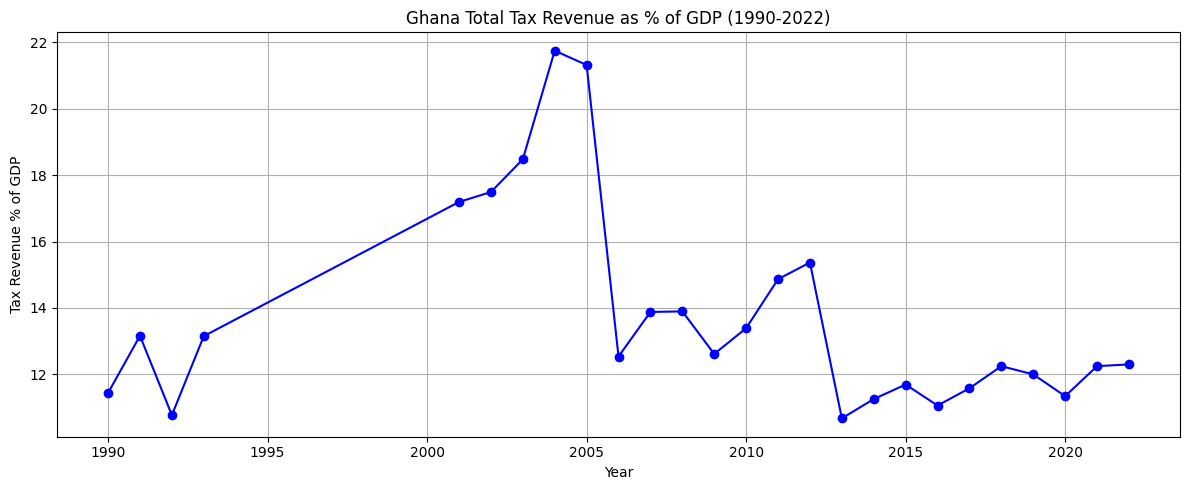

In [3]:
import matplotlib.pyplot as plt

df_total = pd.read_csv('ghana_tax_revenue.csv')
df_total['Year'] = df_total['Year'].astype(int)
df_total = df_total[(df_total['Year'] >= 1990) & (df_total['Year'] <= 2022)]

plt.figure(figsize=(12, 5))
plt.plot(df_total['Year'], df_total['Tax_Revenue_PCT_GDP'], marker='o', color='blue')
plt.title('Ghana Total Tax Revenue as % of GDP (1990-2022)')
plt.xlabel('Year')
plt.ylabel('Tax Revenue % of GDP')
plt.grid(True)
plt.tight_layout()
plt.savefig('ghana_tax_trend.png')
plt.show()

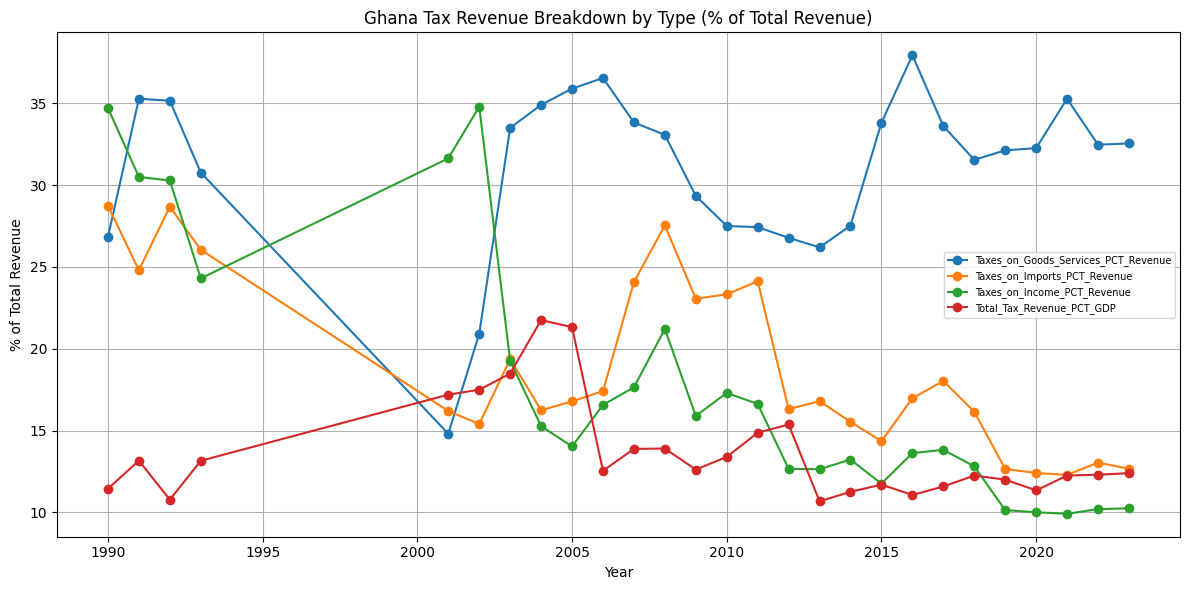

In [4]:
df_breakdown = pd.read_csv('ghana_tax_breakdown.csv')
df_breakdown['Year'] = df_breakdown['Year'].astype(int)

plt.figure(figsize=(12, 6))

for indicator in df_breakdown['Indicator'].unique():
    subset = df_breakdown[df_breakdown['Indicator'] == indicator]
    plt.plot(subset['Year'], subset['Value'], marker='o', label=indicator)

plt.title('Ghana Tax Revenue Breakdown by Type (% of Total Revenue)')
plt.xlabel('Year')
plt.ylabel('% of Total Revenue')
plt.legend(fontsize=7)
plt.grid(True)
plt.tight_layout()
plt.savefig('ghana_tax_breakdown_chart.png')
plt.show()

In [5]:
df_breakdown.to_csv('ghana_tax_breakdown_export.csv', index=False)

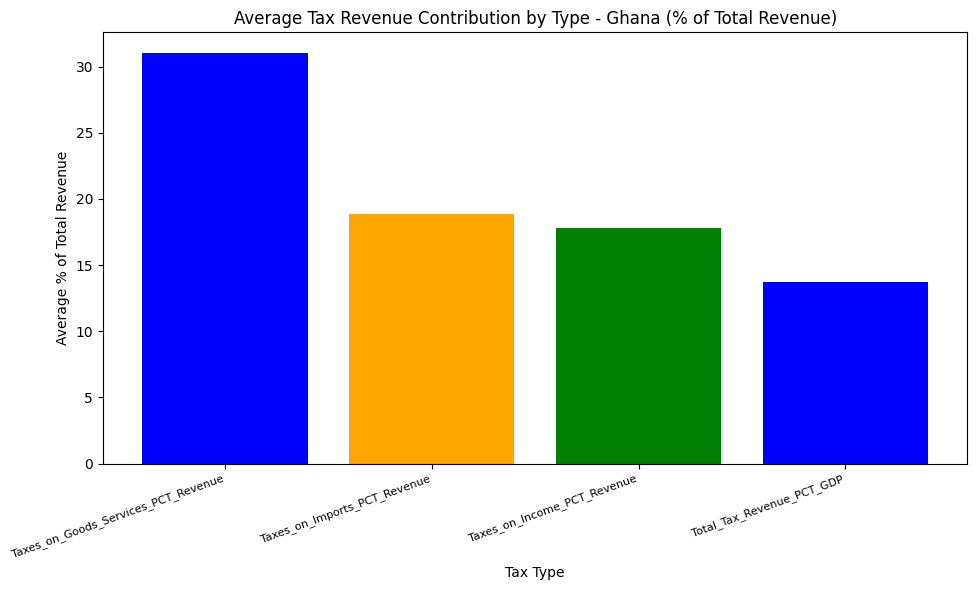

In [6]:
df_breakdown = pd.read_csv('ghana_tax_breakdown.csv')
df_breakdown['Year'] = df_breakdown['Year'].astype(int)

avg_by_type = df_breakdown.groupby('Indicator')['Value'].mean().reset_index()
avg_by_type = avg_by_type.sort_values('Value', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(avg_by_type['Indicator'], avg_by_type['Value'], color=['blue', 'orange', 'green'])
plt.title('Average Tax Revenue Contribution by Type - Ghana (% of Total Revenue)')
plt.xlabel('Tax Type')
plt.ylabel('Average % of Total Revenue')
plt.xticks(rotation=20, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('ghana_tax_avg_bar.png')
plt.show()

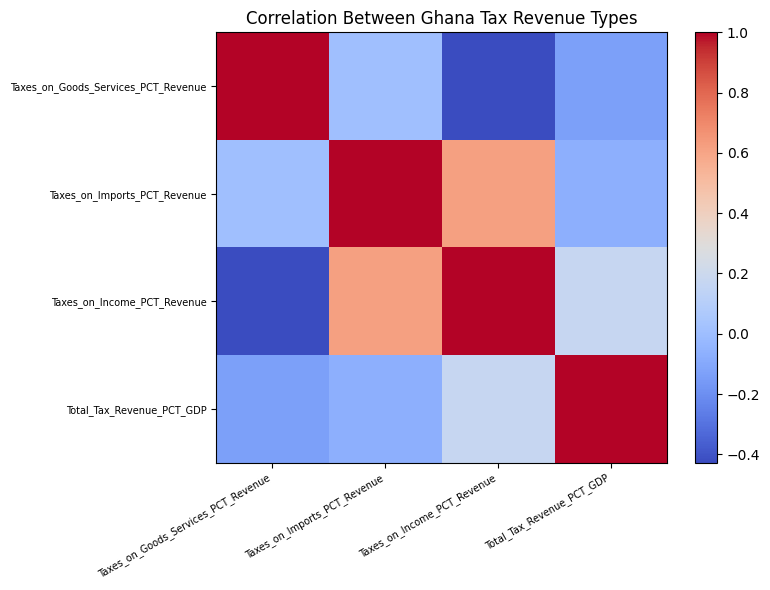

In [7]:
import numpy as np

df_pivot = df_breakdown.pivot_table(index='Year', columns='Indicator', values='Value')
df_pivot = df_pivot.dropna()

correlation = df_pivot.corr()

plt.figure(figsize=(8, 6))
plt.imshow(correlation, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=30, ha='right', fontsize=7)
plt.yticks(range(len(correlation.columns)), correlation.columns, fontsize=7)
plt.title('Correlation Between Ghana Tax Revenue Types')
plt.tight_layout()
plt.savefig('ghana_tax_correlation.png')
plt.show()

In [8]:
print("=== GHANA TAX REVENUE SUMMARY STATISTICS ===")
print("\nTotal Tax Revenue (% of GDP):")
print(df_total['Tax_Revenue_PCT_GDP'].describe().round(2))

print("\nTax Breakdown by Type (% of Total Revenue):")
print(df_breakdown.groupby('Indicator')['Value'].describe().round(2))

=== GHANA TAX REVENUE SUMMARY STATISTICS ===

Total Tax Revenue (% of GDP):
count    26.00
mean     13.76
std       3.09
min      10.67
25%      11.61
50%      12.57
75%      14.62
max      21.75
Name: Tax_Revenue_PCT_GDP, dtype: float64

Tax Breakdown by Type (% of Total Revenue):
                                     count   mean   std    min    25%    50%  \
Indicator                                                                      
Taxes_on_Goods_Services_PCT_Revenue   27.0  31.04  5.10  14.80  27.52  32.48   
Taxes_on_Imports_PCT_Revenue          27.0  18.85  5.30  12.28  15.46  16.79   
Taxes_on_Income_PCT_Revenue           27.0  17.82  7.93   9.91  12.65  15.27   
Total_Tax_Revenue_PCT_GDP             27.0  13.71  3.04  10.67  11.63  12.53   

                                       75%    max  
Indicator                                          
Taxes_on_Goods_Services_PCT_Revenue  34.38  37.95  
Taxes_on_Imports_PCT_Revenue         23.70  28.74  
Taxes_on_Income_PCT_Revenue 

Ghana Tax Revenue Performance Analysis (1990-2022)
A Data-Driven Assessment Using World Bank Fiscal Indicators

1. Introduction
Ghana's tax revenue system is administered primarily by the Ghana Revenue Authority (GRA), established in 2009 to consolidate tax collection under one body. This analysis examines Ghana's tax revenue performance from 1990 to 2022 using World Bank fiscal data across four key indicators: total tax revenue as a percentage of GDP, taxes on goods and services, taxes on imports, and taxes on income.

2. Data Source and Methodology
Data Source: World Bank Open Data API
Indicators used:

GC.TAX.TOTL.GD.ZS: Total tax revenue as % of GDP
GC.TAX.GSRV.RV.ZS: Taxes on goods and services as % of revenue
GC.TAX.IMPT.ZS: Taxes on imports as % of revenue
GC.TAX.INTT.RV.ZS: Taxes on income as % of revenue

Tools: Python, pandas, matplotlib
Period: 1990 to 2022

3. Key Findings
3.1 Total Tax Revenue as % of GDP

The 32-year average was 13.76% of GDP
Ghana recorded its lowest tax-to-GDP ratio in the early 1990s at around 10.67%
Revenue rose steadily through the late 1990s, peaking at 21.75% of GDP around 2004 to 2006
After 2006, revenue declined sharply and stabilised between 11% and 14% of GDP
Ghana's tax-to-GDP ratio remains below the African Union benchmark of 20%

3.2 Taxes on Goods and Services

This is Ghana's largest single revenue source, averaging 31.04% of total tax revenue
It peaked at 37.95% and dropped to a low of 14.80%
The high reliance on indirect taxes signals a narrow direct tax base
VAT introduced in 1998 drove the rise in goods and services revenue through the 2000s

3.3 Taxes on Imports

Averaged 18.85% of total revenue over the period
Peaked at 28.74% and dropped to 12.28%
Import tax revenue is highly sensitive to global commodity prices and trade volumes
Ghana's trade liberalisation policies and ECOWAS tariff agreements reduced import tax yields over time

3.4 Taxes on Income

Averaged 17.82% of total revenue
High standard deviation of 7.93 indicates significant year-to-year volatility
Income tax collection is constrained by the large informal economy in Ghana
Formal sector employment, which drives PAYE income tax, covers a minority of workers


4. Key Problems Identified
Problem 1: Tax-to-GDP Ratio Below African Benchmarks
Ghana's average of 13.76% of GDP falls below the African Union's recommended minimum of 20%. Low tax mobilisation limits government spending capacity on infrastructure, health, and education. Peer countries such as South Africa and Kenya consistently achieve ratios above 18%.
Problem 2: Over-Reliance on Indirect Taxation
Goods and services taxes account for 31% of revenue on average. This creates a regressive tax structure where lower-income households bear a disproportionate share of the tax burden through VAT and levies on everyday consumption.
Problem 3: Declining Import Tax Revenue
Import taxes declined from peaks above 28% to below 13% of total revenue. Trade agreements and tariff reductions have eroded this revenue stream. Ghana has not fully replaced lost import tax revenue with domestic tax alternatives.
Problem 4: Income Tax Underperformance
With a mean of 17.82% and high volatility, income tax collection is inconsistent. Ghana's informal economy accounts for over 80% of employment. Most workers operate outside the formal tax net, which significantly reduces personal income tax yield.
Problem 5: Post-2006 Revenue Collapse
Tax revenue fell sharply after the 2004 to 2006 peak and never recovered to those levels. This coincided with rising government expenditure, fiscal deficits, and debt accumulation. The structural decline in tax effort has contributed to Ghana's repeated IMF programme engagements.
Problem 6: Narrow Tax Base
All four indicators show that Ghana's tax system depends on a small number of revenue streams. There is no significant capital gains tax contribution, minimal property tax collection, and limited corporate tax diversification beyond the extractive sector.

5. Recommendations

Broaden the tax base by bringing informal sector operators into the tax net through presumptive taxation
Strengthen property tax administration at the district level
Invest in GRA digital systems to improve compliance and reduce leakage
Reduce dependence on import taxes by developing domestic consumption and income tax capacity
Implement progressive tax reforms to reduce the burden on low-income households


6. Conclusion
Ghana's tax revenue performance shows structural weaknesses that have persisted over three decades. The over-reliance on indirect taxes, a shrinking import tax base, and a large untaxed informal sector limit Ghana's fiscal capacity. Addressing these issues requires systemic reform of tax administration, policy, and enforcement.